In [1]:
from google.colab import files
uploaded = files.upload()

Saving iot_data.csv to iot_data.csv


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json

In [ ]:
df = pd.read_csv("iot_data.csv")

In [5]:
print(df.head())

     r_id       reg_no                                       field_value3  \
0  107342  25PSITCS011  {"884":"0.00","885":"0.00","886":"27.94","887"...   
1  107341  25PSITCS011  {"884":"0.00","885":"0.00","886":"28.06","887"...   
2  107340  25PSITCS011  {"884":"0.00","885":"0.00","886":"27.75","887"...   
3  107339  25PSITCS011  {"884":"17.23","885":"93.00","886":"27.81","88...   
4  107298  25PSITCS011  {"884":"0.00","885":"0.00","886":"29.88","887"...   

   p_id             iot_date  
0   NaN  2026-05-05 16:48:37  
1   NaN  2026-05-05 16:42:25  
2   NaN  2026-05-05 16:38:46  
3   NaN  2026-05-05 16:37:16  
4   NaN  2026-05-04 19:27:40  


In [8]:
df["parsed"] = df["field_value3"].apply(lambda x: json.loads(x))

df["BPM"] = df["parsed"].apply(lambda x: float(x.get("884", 0)))
df["SPO2"] = df["parsed"].apply(lambda x: float(x.get("885", 0)))
df["Body_Temp"] = df["parsed"].apply(lambda x: float(x.get("886", 0)))
df["Ambient_Temp"] = df["parsed"].apply(lambda x: float(x.get("887", 0)))
df["Humidity"] = df["parsed"].apply(lambda x: float(x.get("888", 0)))

df_clean = df[["BPM", "SPO2", "Body_Temp", "Ambient_Temp", "Humidity"]]

df_clean.insert(0, "SNo", range(1, len(df_clean)+1))

In [9]:
print(df_clean.head())

   SNo    BPM  SPO2  Body_Temp  Ambient_Temp  Humidity
0    1   0.00   0.0      27.94          29.3      63.0
1    2   0.00   0.0      28.06          28.9      63.0
2    3   0.00   0.0      27.75          28.5      64.0
3    4  17.23  93.0      27.81          28.0      65.0
4    5   0.00   0.0      29.88          30.8      56.0


In [10]:
df_clean

,SNo,BPM,SPO2,Body_Temp,Ambient_Temp,Humidity
0,1,0.00,0.0,27.94,29.3,63.0
1,2,0.00,0.0,28.06,28.9,63.0
2,3,0.00,0.0,27.75,28.5,64.0
3,4,17.23,93.0,27.81,28.0,65.0
4,5,0.00,0.0,29.88,30.8,56.0
...,...,...,...,...,...,...
112,113,48.69,94.0,24.38,0.0,0.0
113,114,75.67,97.0,24.44,0.0,0.0
114,115,70.92,97.0,24.44,0.0,0.0
115,116,0.00,0.0,24.31,0.0,0.0


In [11]:
print(df_clean.describe())

              SNo         BPM        SPO2   Body_Temp  Ambient_Temp  \
count  117.000000  117.000000  117.000000  117.000000    116.000000   
mean    59.000000   31.582051   43.803419   24.865983     20.085345   
std     33.919021   33.829339   48.352556    5.233490     12.501654   
min      1.000000    0.000000    0.000000   19.310000      0.000000   
25%     30.000000    0.000000    0.000000   19.440000      0.000000   
50%     59.000000   16.720000    0.000000   24.440000     22.200000   
75%     88.000000   70.000000   97.000000   30.000000     30.800000   
max    117.000000   83.350000   99.000000   33.810000     31.800000   

         Humidity  
count  116.000000  
mean    42.146552  
std     25.102660  
min      0.000000  
25%      0.000000  
50%     55.000000  
75%     58.000000  
max     65.000000  


In [12]:
# Count invalid values (zeros)
print("Invalid values count:")
print("BPM zeros:", (df_clean["BPM"] == 0).sum())
print("SPO2 zeros:", (df_clean["SPO2"] == 0).sum())

Invalid values count:
BPM zeros: 56
SPO2 zeros: 64


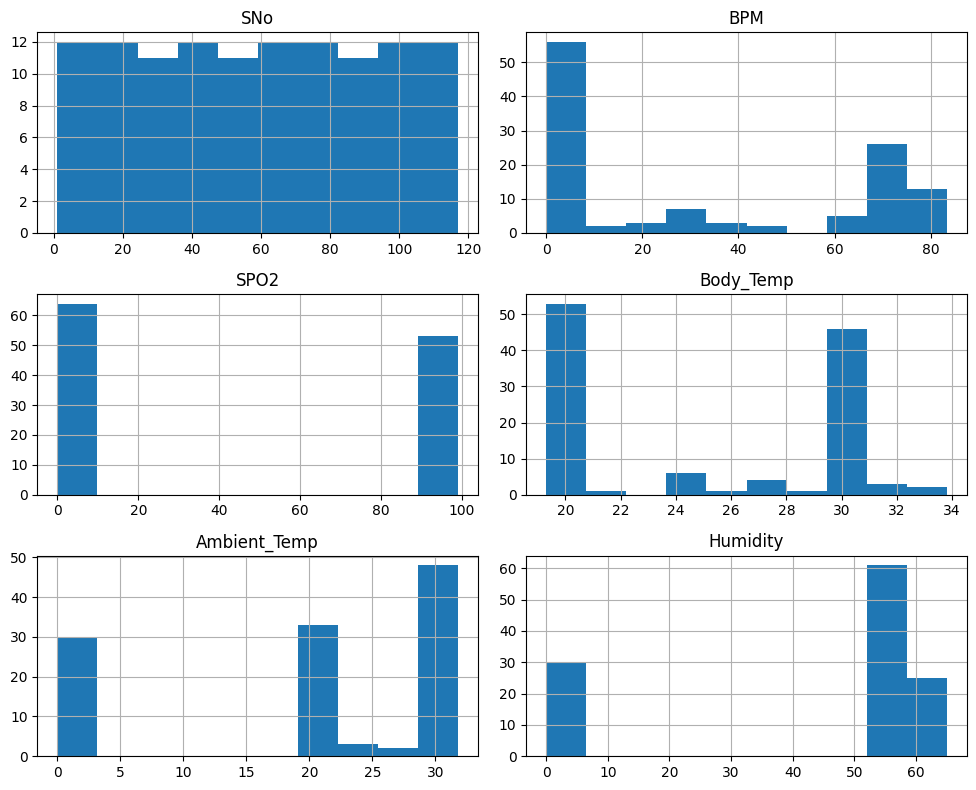

In [13]:
df_clean.hist(figsize=(10,8))
plt.tight_layout()
plt.show()

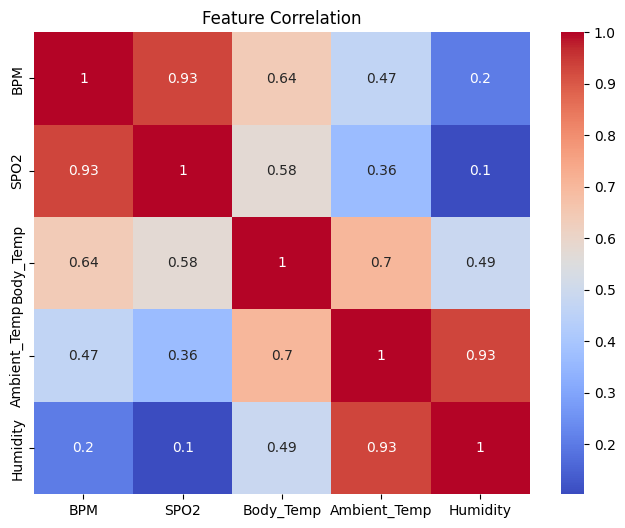

In [14]:
plt.figure(figsize=(8,6))
sns.heatmap(df_clean.drop("SNo", axis=1).corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

In [15]:
df_model = df_clean.copy()

# Replace invalid zero readings with NaN
sensor_cols = ["BPM", "SPO2", "Body_Temp", "Ambient_Temp", "Humidity"]
df_model[sensor_cols] = df_model[sensor_cols].replace(0, np.nan)

# Check missing values after replacement
print("Missing values after replacing zeros:")
print(df_model.isnull().sum())

# Fill missing values with median
for col in sensor_cols:
    df_model[col] = df_model[col].fillna(df_model[col].median())

# Remove duplicates if any
df_model = df_model.drop_duplicates()

# Final cleaned preview
print(df_model.head())

# Verify zeros are gone
print("\nZero count after cleaning:")
print((df_model[sensor_cols] == 0).sum())

Missing values after replacing zeros:
SNo              0
BPM             56
SPO2            64
Body_Temp        0
Ambient_Temp    31
Humidity        31
dtype: int64
   SNo    BPM  SPO2  Body_Temp  Ambient_Temp  Humidity
0    1  70.00  97.0      27.94          29.3      63.0
1    2  70.00  97.0      28.06          28.9      63.0
2    3  70.00  97.0      27.75          28.5      64.0
3    4  17.23  93.0      27.81          28.0      65.0
4    5  70.00  97.0      29.88          30.8      56.0

Zero count after cleaning:
BPM             0
SPO2            0
Body_Temp       0
Ambient_Temp    0
Humidity        0
dtype: int64


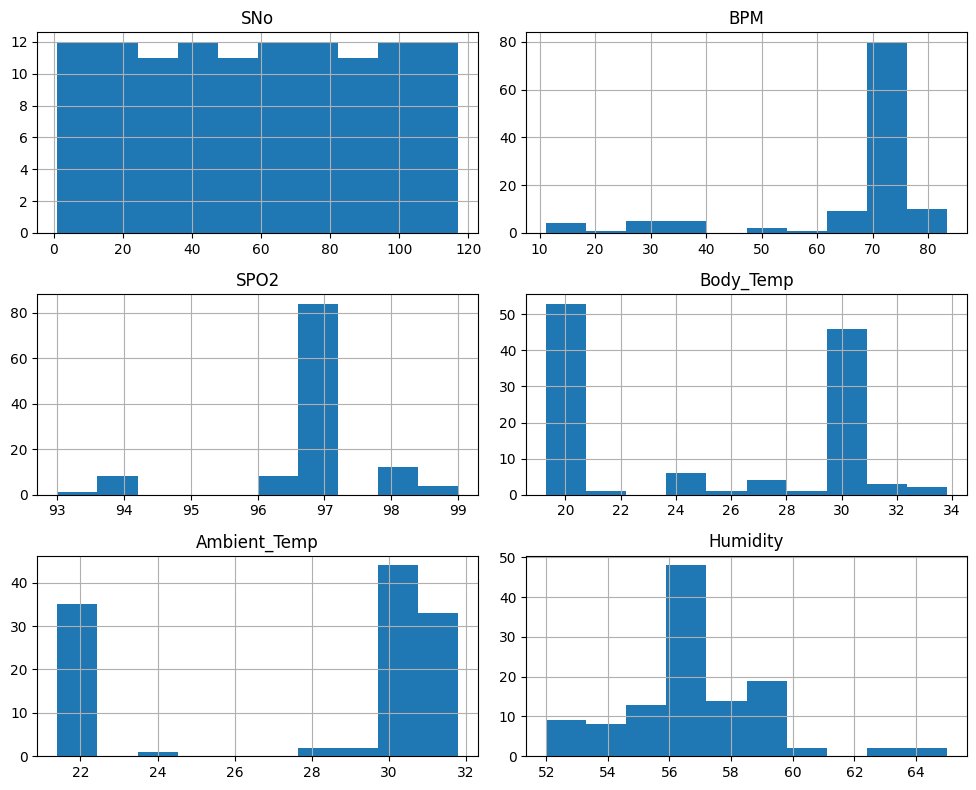

In [16]:
df_model.hist(figsize=(10,8))
plt.tight_layout()
plt.show()

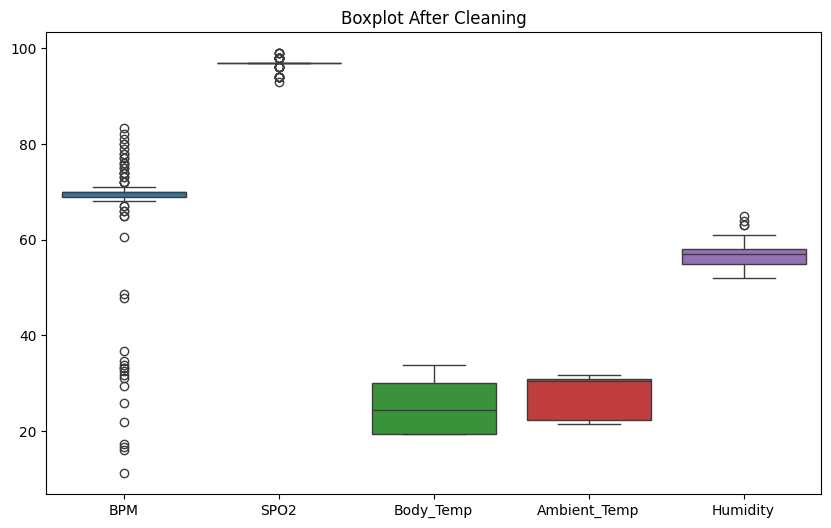

In [17]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df_model.drop("SNo", axis=1))
plt.title("Boxplot After Cleaning")
plt.show()

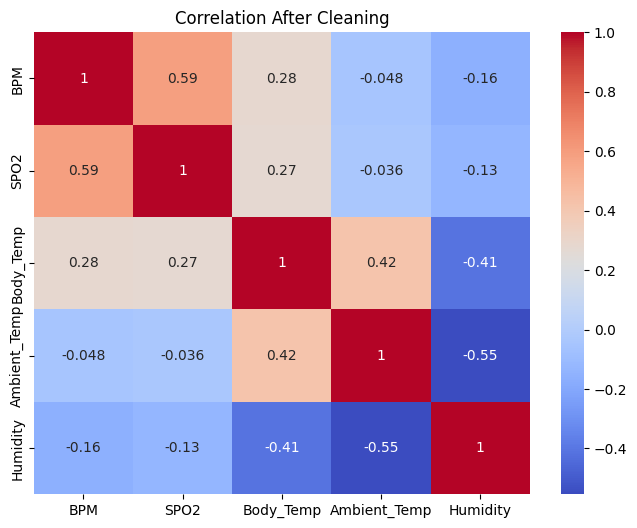

In [18]:
plt.figure(figsize=(8,6))
sns.heatmap(df_model.drop("SNo", axis=1).corr(), annot=True, cmap="coolwarm")
plt.title("Correlation After Cleaning")
plt.show()

In [19]:
# IQR method for BPM
Q1 = df_model["BPM"].quantile(0.25)
Q3 = df_model["BPM"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Clip values
df_model["BPM"] = df_model["BPM"].clip(lower_bound, upper_bound)

# Check again
print("New BPM range:", df_model["BPM"].min(), df_model["BPM"].max())

New BPM range: 67.5 71.5


In [20]:
# Features only (drop SNo)
X = df_model.drop("SNo", axis=1)

# Check data
print(X.head())
print("Shape:", X.shape)

    BPM  SPO2  Body_Temp  Ambient_Temp  Humidity
0  70.0  97.0      27.94          29.3      63.0
1  70.0  97.0      28.06          28.9      63.0
2  70.0  97.0      27.75          28.5      64.0
3  67.5  93.0      27.81          28.0      65.0
4  70.0  97.0      29.88          30.8      56.0
Shape: (117, 5)


In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (93, 5)
Test shape: (24, 5)


In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit ONLY on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data
X_test_scaled = scaler.transform(X_test)

In [26]:
from sklearn.ensemble import IsolationForest

model = IsolationForest(contamination=0.1, random_state=42)

model.fit(X_train_scaled)

IsolationForest(contamination=0.1, random_state=42)

In [27]:
y_test_pred = model.predict(X_test_scaled)

# Convert labels
y_test_pred = ["Normal" if x == 1 else "Abnormal" for x in y_test_pred]

import pandas as pd
print(pd.Series(y_test_pred).value_counts())

Normal      22
Abnormal     2
Name: count, dtype: int64


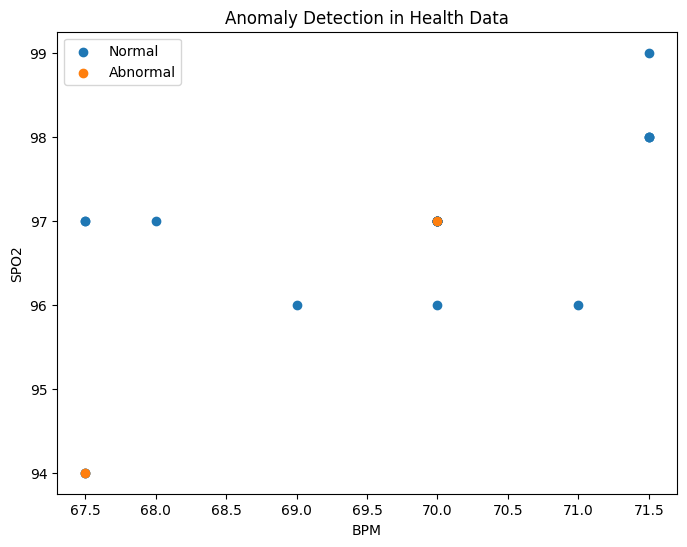

In [28]:
import matplotlib.pyplot as plt

# Convert test data back to DataFrame
df_test = X_test.copy()
df_test["Anomaly"] = y_test_pred

# Plot
plt.figure(figsize=(8,6))

normal = df_test[df_test["Anomaly"] == "Normal"]
abnormal = df_test[df_test["Anomaly"] == "Abnormal"]

plt.scatter(normal["BPM"], normal["SPO2"], label="Normal")
plt.scatter(abnormal["BPM"], abnormal["SPO2"], label="Abnormal")

plt.xlabel("BPM")
plt.ylabel("SPO2")
plt.title("Anomaly Detection in Health Data")
plt.legend()
plt.show()

In [29]:
import joblib

joblib.dump(model, "anomaly_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']